In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import scipy.stats as stats   # Q-Q plot for checking Data Normalization
from scipy import stats       # Test for checking Data Normalization
from scipy.stats import anderson, kstest, shapiro   # Test for checking Data Normalization
from sklearn.preprocessing import LabelEncoder    # convert object and category variables
from sklearn.model_selection import train_test_split # Splitting
from sklearn.preprocessing import RobustScaler # Normalization
from sklearn.preprocessing import MinMaxScaler # Normalization
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score # Scores for ML Models
import warnings


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
data = pd.read_csv('/healthcare-dataset-stroke-data.csv')

In [ ]:
#columns of dataset
data.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [ ]:
#first five entries in the datset
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
#last five entries in the dataset
data.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [ ]:

# Perform statistical analysis of numerical features
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


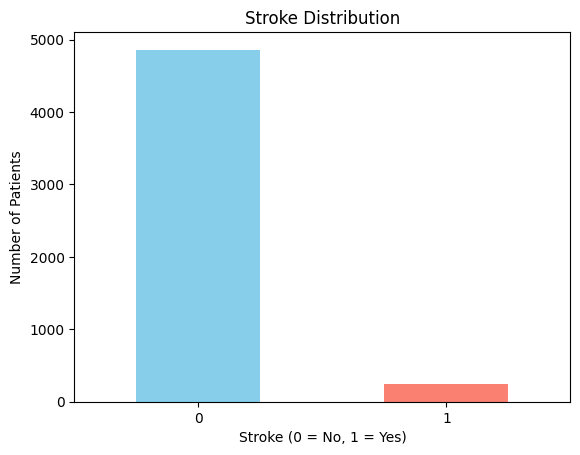

In [ ]:
# Stroke Distribution Data Visualization

df['stroke'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Stroke Distribution")
plt.xlabel("Stroke (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()


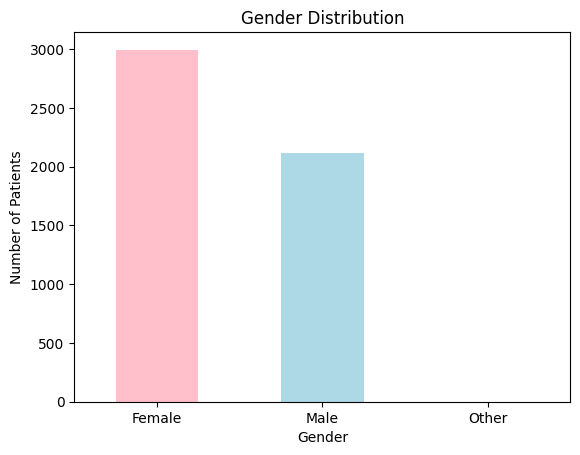

In [ ]:
# Gender Distribution Data Visualization
import matplotlib.pyplot as plt

df['gender'].value_counts().plot(kind='bar', color=['pink', 'lightblue', 'gray'])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()


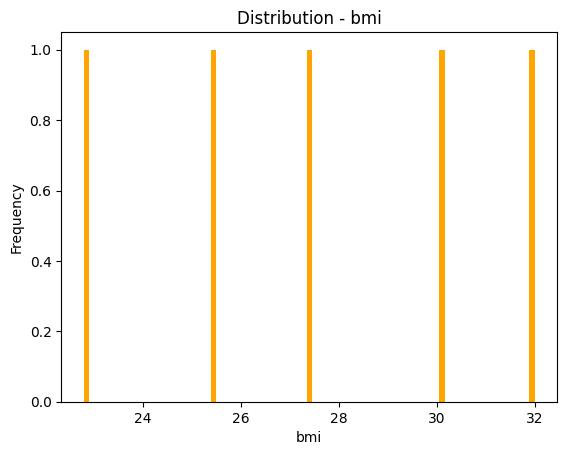

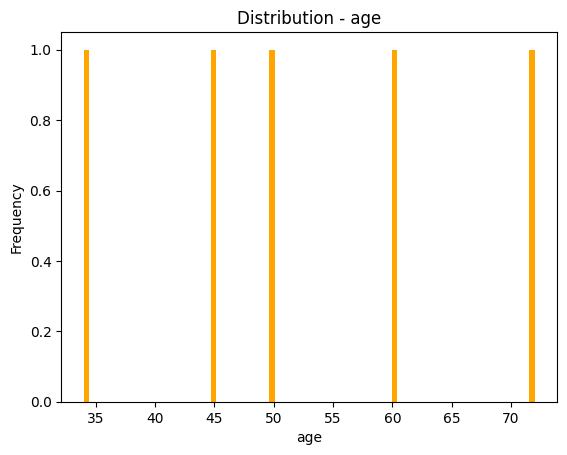

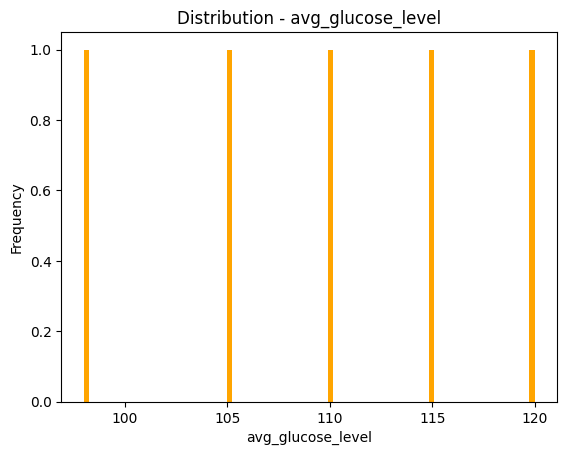

In [ ]:
def plotHistogram(variable):
    plt.figure()
    plt.hist(data[variable], bins=85, color="orange")
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("Distribution - {}".format(variable))
    plt.show()

numeric_variables = ["bmi", "age", "avg_glucose_level"]

for var in numeric_variables:
    plotHistogram(var)


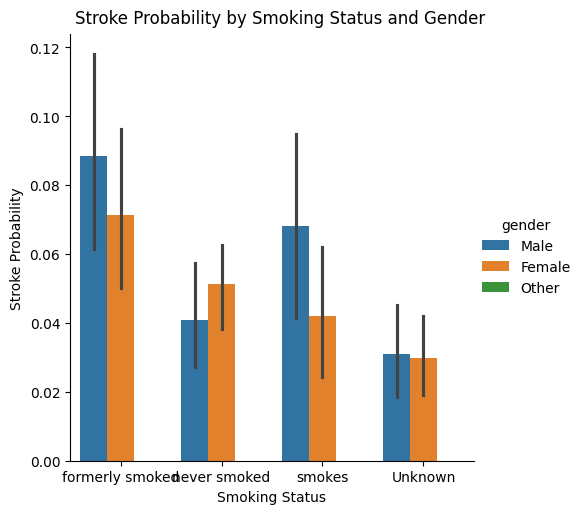

In [ ]:
# Plot with hue to color bars by gender
g = sns.catplot(x="smoking_status", y="stroke", hue="gender", kind="bar", data=df)

g.set_axis_labels("Smoking Status", "Stroke Probability")
g.fig.suptitle("Stroke Probability by Smoking Status and Gender", y=1.02)
plt.show()


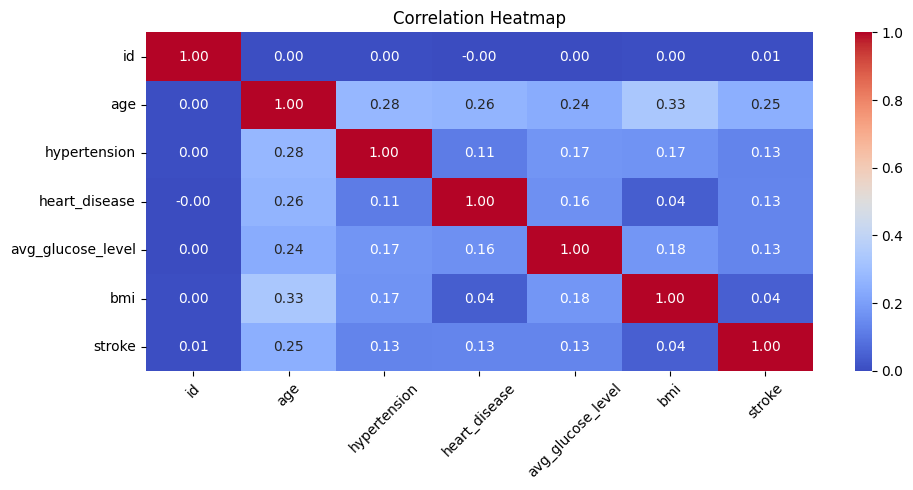

In [ ]:
# Select only numerical columns
df_num = df.select_dtypes(include=[np.number])

# Plot correlation heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(df_num.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.xticks(rotation=45)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [ ]:
(
    df[["hypertension", "stroke"]]
    .groupby("hypertension", as_index=False)
    .mean()
    .sort_values(by="stroke", ascending=False)
)


,hypertension,stroke
1,1,0.132530
0,0,0.039679


In [ ]:
(
    df[["smoking_status", "stroke"]]
    .groupby("smoking_status", as_index=False)
    .mean()
    .sort_values(by="stroke", ascending=False)
)


,smoking_status,stroke
1,formerly smoked,0.079096
3,smokes,0.053232
2,never smoked,0.047569
0,Unknown,0.030440


In [ ]:
(
    df[["heart_disease", "stroke"]]
    .groupby("heart_disease", as_index=False)
    .mean()
    .sort_values(by="stroke", ascending=False)
)


,heart_disease,stroke
1,1,0.170290
0,0,0.041787


In [ ]:
(
    df[["gender", "stroke"]]
    .groupby("gender", as_index=False)
    .mean()
    .sort_values(by="stroke", ascending=False)
)

,gender,stroke
1,Male,0.051064
0,Female,0.047094
2,Other,0.000000


In [ ]:
from collections import Counter
import numpy as np

def detect_outliers(data, features):
    outlier_indices = []

    for c in features:
        # 1st quartile
        Q1 = np.percentile(data[c], 25)
        # 3rd quartile
        Q3 = np.percentile(data[c], 75)
        # IQR
        IQR = Q3 - Q1
        # Outlier step
        outlier_step = IQR * 1.5
        # Detect outliers and their indices
        outlier_list_col = data[(data[c] < Q1 - outlier_step) | (data[c] > Q3 + outlier_step)].index
        # Store indices
        outlier_indices.extend(outlier_list_col)

    # Count how many times each index appears
    outlier_indices = Counter(outlier_indices)

    # Keep only those that are outliers in more than 2 features
    multiple_outliers = [i for i, v in outlier_indices.items() if v > 2]

    return multiple_outliers


In [ ]:
df.loc[detect_outliers(df, ['age', 'hypertension', 'heart_disease',
       'avg_glucose_level', 'bmi', 'stroke'])]


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
17,34120,Male,75.0,1,0,Yes,Private,Urban,221.29,25.8,smokes,1
21,13861,Female,52.0,1,0,Yes,Self-employed,Urban,233.29,48.9,never smoked,1
30,43717,Male,57.0,1,0,Yes,Private,Urban,212.08,44.2,smokes,1
...,...,...,...,...,...,...,...,...,...,...,...,...
155,24669,Female,77.0,0,1,Yes,Private,Rural,231.56,36.9,never smoked,1
189,66955,Male,61.0,0,1,Yes,Private,Urban,209.86,NaN,Unknown,1
215,68025,Female,79.0,0,1,No,Private,Urban,205.33,31.0,smokes,1
219,31421,Male,73.0,0,1,Yes,Govt_job,Rural,219.73,28.6,never smoked,1


In [ ]:
df_len = len(df)


In [ ]:
df.columns[df.isnull().any()]


Index(['bmi'], dtype='object')

In [ ]:
df.isnull().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


In [7]:
import pandas as pd

df = pd.read_csv('/healthcare-dataset-stroke-data.csv')
df[df["bmi"].isnull()]


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
13,8213,Male,78.0,0,1,Yes,Private,Urban,219.84,NaN,Unknown,1
19,25226,Male,57.0,0,1,No,Govt_job,Urban,217.08,NaN,Unknown,1
27,61843,Male,58.0,0,0,Yes,Private,Rural,189.84,NaN,Unknown,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5039,42007,Male,41.0,0,0,No,Private,Rural,70.15,NaN,formerly smoked,0
5048,28788,Male,40.0,0,0,Yes,Private,Urban,191.15,NaN,smokes,0
5093,32235,Female,45.0,1,0,Yes,Govt_job,Rural,95.02,NaN,smokes,0
5099,7293,Male,40.0,0,0,Yes,Private,Rural,83.94,NaN,smokes,0


In [8]:
bmi_mean = df["bmi"].mean()
df["bmi"] = df["bmi"].fillna(bmi_mean)


In [11]:
df[df["bmi"].isnull()]

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


In [20]:
if "gender" in df.columns:
    df = pd.get_dummies(df, columns=["gender"], drop_first=True)


In [23]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
categorical_columns = df.select_dtypes(include=["object"]).columns
print(categorical_columns)

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])


Index(['ever_married', 'work_type', 'Residence_type', 'smoking_status'], dtype='object')


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   int64  
 5   work_type          5110 non-null   int64  
 6   Residence_type     5110 non-null   int64  
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   int64  
 10  stroke             5110 non-null   int64  
 11  gender_Male        5110 non-null   bool   
 12  gender_Other       5110 non-null   bool   
dtypes: bool(2), float64(3), int64(8)
memory usage: 449.2 KB


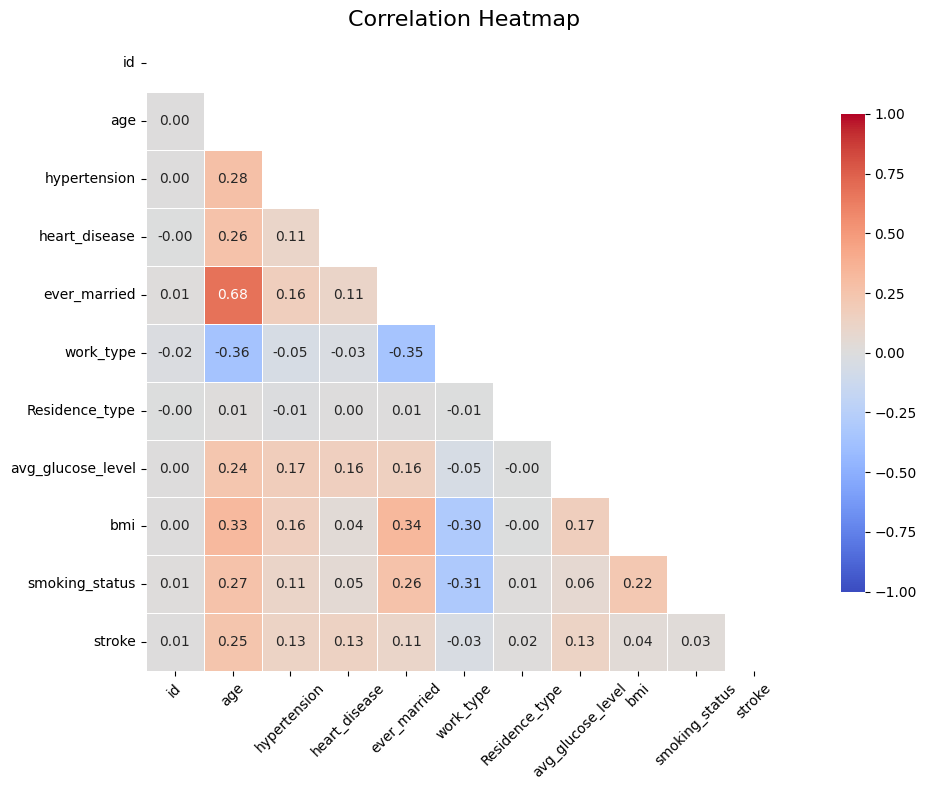

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
df_num = df.select_dtypes(include=[np.number])

# Compute the correlation matrix
corr = df_num.corr()

# Create a mask for the upper triangle (optional: hides duplicate half)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.75}
)

plt.xticks(rotation=45)
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()


In [27]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Split features and target
X = df.drop("stroke", axis=1)
y = df["stroke"]

# 2. Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Define individual models
rf = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier(random_state=42)

# 4. VotingClassifier (Ensemble model)
voting_clf = VotingClassifier(
    estimators=[("rf", rf), ("knn", knn), ("dt", dt)],
    voting="hard"  # or 'soft' if using predict_proba
)

# 5. Fit the model
voting_clf.fit(X_train, y_train)

# 6. Predict and evaluate
y_pred = voting_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Voting Classifier Accuracy:", round(accuracy * 100, 2), "%")


Voting Classifier Accuracy: 95.01 %


In [26]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop("stroke", axis=1)
y = df["stroke"]

# Train/test split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify preserves class balance
)

# Print sample counts
print("X_train:", len(X_train))
print("X_test:", len(X_test))
print("y_train:", len(y_train))
print("y_test:", len(y_test))


X_train: 4088
X_test: 1022
y_train: 4088
y_test: 1022


In [29]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

random_state = 42

# Define classifiers
classifier = [
    DecisionTreeClassifier(random_state=random_state),
    RandomForestClassifier(random_state=random_state),
    KNeighborsClassifier()
]

# Parameter grids for tuning
dt_param_grid = {
    "min_samples_split": range(10, 500, 20),
    "max_depth": range(1, 20, 2)
}

rf_param_grid = {
    "max_features": [1, 3, 10],
    "min_samples_split": [2, 3, 10],
    "min_samples_leaf": [1, 3, 10],
    "bootstrap": [False],
    "n_estimators": [100, 300],
    "criterion": ["gini"]
}

knn_param_grid = {
    "n_neighbors": np.linspace(1, 19, 10, dtype=int).tolist(),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# Combine parameter grids
classifier_param = [dt_param_grid, rf_param_grid, knn_param_grid]


In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

best_models = {}

for model, params in zip(classifier, classifier_param):
    print(f"\nTuning {model.__class__.__name__}...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    print(f"Best Score for {model.__class__.__name__}: {round(grid.best_score_ * 100, 2)}%")
    print(f"Best Params: {grid.best_params_}")

    best_models[model.__class__.__name__] = grid.best_estimator_



Tuning DecisionTreeClassifier...
Fitting 5 folds for each of 250 candidates, totalling 1250 fits
Best Score for DecisionTreeClassifier: 95.13%
Best Params: {'max_depth': 1, 'min_samples_split': 10}

Tuning RandomForestClassifier...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Score for RandomForestClassifier: 95.13%
Best Params: {'bootstrap': False, 'criterion': 'gini', 'max_features': 1, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Tuning KNeighborsClassifier...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Score for KNeighborsClassifier: 95.13%
Best Params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}


In [31]:
cv_result = []
best_models = {}

for model, params in zip(classifier, classifier_param):
    print(f"\nTuning {model.__class__.__name__}...")

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=5,
        scoring="accuracy",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_score = grid.best_score_
    cv_result.append(best_score)  # Collect CV mean accuracy

    print(f"Best Score for {model.__class__.__name__}: {round(best_score * 100, 2)}%")
    print(f"Best Params: {grid.best_params_}")

    best_models[model.__class__.__name__] = grid.best_estimator_



Tuning DecisionTreeClassifier...
Fitting 5 folds for each of 250 candidates, totalling 1250 fits
Best Score for DecisionTreeClassifier: 95.13%
Best Params: {'max_depth': 1, 'min_samples_split': 10}

Tuning RandomForestClassifier...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Score for RandomForestClassifier: 95.13%
Best Params: {'bootstrap': False, 'criterion': 'gini', 'max_features': 1, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}

Tuning KNeighborsClassifier...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Score for KNeighborsClassifier: 95.13%
Best Params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}


In [32]:
cv_results = pd.DataFrame({
    "Cross Validation Accuracy Means": cv_result,
    "ML Models": ["DecisionTreeClassifier", "RandomForestClassifier", "KNeighborsClassifier"]
})

cv_results


,Cross Validation Accuracy Means,ML Models
0,0.951321,DecisionTreeClassifier
1,0.951321,RandomForestClassifier
2,0.951321,KNeighborsClassifier


<ipython-input-33-acf2a8845b2c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  s = sns.barplot(data=cv_results, x="ML Models", y="Cross Validation Accuracy Means", palette="viridis")


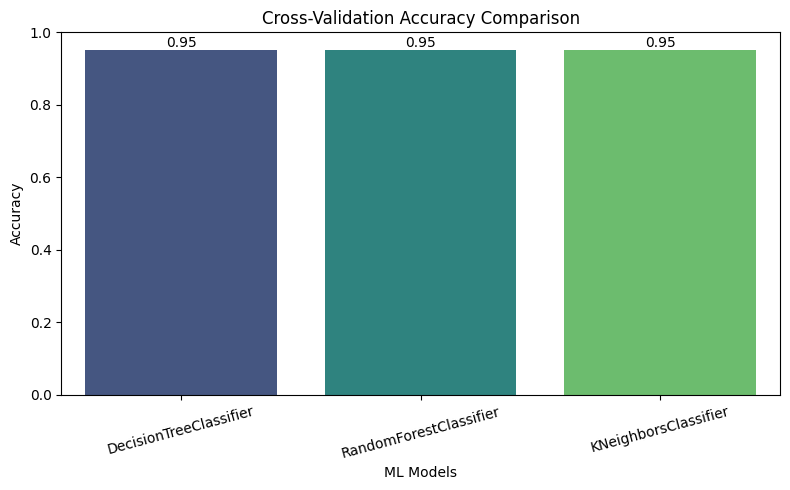

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
s = sns.barplot(data=cv_results, x="ML Models", y="Cross Validation Accuracy Means", palette="viridis")

# Add value labels on top of bars
for bar in s.patches:
    s.annotate(f'{bar.get_height():.2f}',
               (bar.get_x() + bar.get_width() / 2, bar.get_height()),
               ha='center', va='bottom', fontsize=10)

plt.title("Cross-Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
